# Figure 4 Neural Dynamics: Population Edge Ramping

Objective:
- Reproduce a Gold & Shadlen Fig.5c-style population firing-rate panel.
- Average across selected right-edge neurons rather than plotting one example neuron.
- Use positive coherence conditions only.
- Plot correct right/Tin choices and incorrect left/Tout choices.
- Left: stimulus-onset aligned traces truncated at each group's mean RT.
- Right: RT-aligned traces over the final pre-decision window.


In [21]:
from __future__ import annotations
%config InlineBackend.figure_format = 'retina'

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUN_ROOT = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure4/fig4_edge_dynamics')
POSITIVE_CONDITIONS = ['drift_p0p125', 'drift_p0p25', 'drift_p0p5', 'drift_p1']
RT_ALIGN_WINDOW_MS = 200
SAVE_PATH = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4/fig4_edge_population_fig5c_style.png')
SAVE_PDF_PATH = SAVE_PATH.with_suffix('.pdf')

OUTCOMES = {
    'correct Tin': {'choice': 1, 'linestyle': '-', 'alpha': 1.0},
    'incorrect Tout': {'choice': -1, 'linestyle': '--', 'alpha': 0.95},
}

plt.rcParams.update({
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


In [22]:
def load_condition(condition_name: str) -> dict:
    dataset_path = RUN_ROOT / 'conditions' / condition_name / 'circuit_dataset.npz'
    if not dataset_path.exists():
        raise FileNotFoundError(dataset_path)

    with np.load(dataset_path, allow_pickle=False) as data:
        metadata = json.loads(str(data['metadata_json'].item()))
        coherence = float(metadata['condition_coherence_values'][0])
        choice = np.asarray(data['choice'])[0]
        hit = np.asarray(data['hit_boundary'])[0].astype(bool)
        rt_ms = np.asarray(data['rt_ms'], dtype=float)[0]
        r_e = np.asarray(data['r_e'], dtype=np.float32)[0]
        selected_edge_indices = np.asarray(metadata['selected_edge_indices'], dtype=int)

    return {
        'condition_name': condition_name,
        'coherence': coherence,
        'choice': choice,
        'hit': hit,
        'rt_ms': rt_ms,
        'r_e': r_e,
        'selected_edge_indices': selected_edge_indices,
    }


def build_population_trace(item: dict, choice_value: int) -> dict | None:
    mask = item['hit'] & (item['choice'] == choice_value) & np.isfinite(item['rt_ms'])
    n_trials = int(mask.sum())
    if n_trials == 0:
        return None

    traces = item['r_e'][mask]
    rt_values = item['rt_ms'][mask]
    population_mean = traces.mean(axis=(0, 2))
    mean_rt = float(np.nanmean(rt_values))
    median_rt = float(np.nanmedian(rt_values))

    return {
        'coherence': item['coherence'],
        'choice': choice_value,
        'n_trials': n_trials,
        'mean_rt': mean_rt,
        'median_rt': median_rt,
        'stim_trace': population_mean,
        'rt_ms': rt_values,
        'traces': traces,
    }


def build_rt_aligned_trace(group: dict, window_ms: int) -> tuple[np.ndarray | None, int]:
    usable = group['rt_ms'] >= window_ms
    traces = group['traces'][usable]
    rts = group['rt_ms'][usable].astype(int)
    if traces.shape[0] == 0:
        return None, 0

    aligned = []
    for trial_trace, rt in zip(traces, rts):
        start = int(rt) - window_ms
        end = int(rt)
        aligned.append(trial_trace[start:end + 1].mean(axis=1))

    return np.asarray(aligned, dtype=float).mean(axis=0), int(len(aligned))


datasets = [load_condition(name) for name in POSITIVE_CONDITIONS]
time_ms = np.arange(datasets[0]['r_e'].shape[1], dtype=float)
selected_edge_indices = datasets[0]['selected_edge_indices']

for item in datasets:
    assert np.array_equal(item['selected_edge_indices'], selected_edge_indices)
    assert item['r_e'].shape[1] == time_ms.size

print('num_selected_edge_units', int(selected_edge_indices.size))
print('selected_edge_global_range', int(selected_edge_indices.min()), int(selected_edge_indices.max()))


num_selected_edge_units 61
selected_edge_global_range 493 553


In [23]:
groups = []
for item in datasets:
    for outcome_name, outcome in OUTCOMES.items():
        group = build_population_trace(item, outcome['choice'])
        if group is None:
            continue
        group['outcome_name'] = outcome_name
        group['rt_trace'], group['rt_aligned_n'] = build_rt_aligned_trace(group, RT_ALIGN_WINDOW_MS)
        group['plot'] = True
        groups.append(group)

print('coherence outcome n_trials rt_aligned_n mean_rt median_rt plot')
for group in groups:
    print(
        f"{group['coherence']:.3g}",
        group['outcome_name'],
        group['n_trials'],
        group['rt_aligned_n'],
        f"{group['mean_rt']:.1f}",
        f"{group['median_rt']:.1f}",
        group['plot'],
    )


coherence outcome n_trials rt_aligned_n mean_rt median_rt plot
0.125 correct Tin 56 54 891.7 765.5 True
0.125 incorrect Tout 28 23 567.1 523.5 True
0.25 correct Tin 62 60 781.9 651.5 True
0.25 incorrect Tout 27 23 820.3 802.0 True
0.5 correct Tin 87 79 678.6 634.0 True
0.5 incorrect Tout 8 8 603.2 383.0 True
1 correct Tin 99 88 503.3 446.0 True
1 incorrect Tout 1 1 223.0 223.0 True


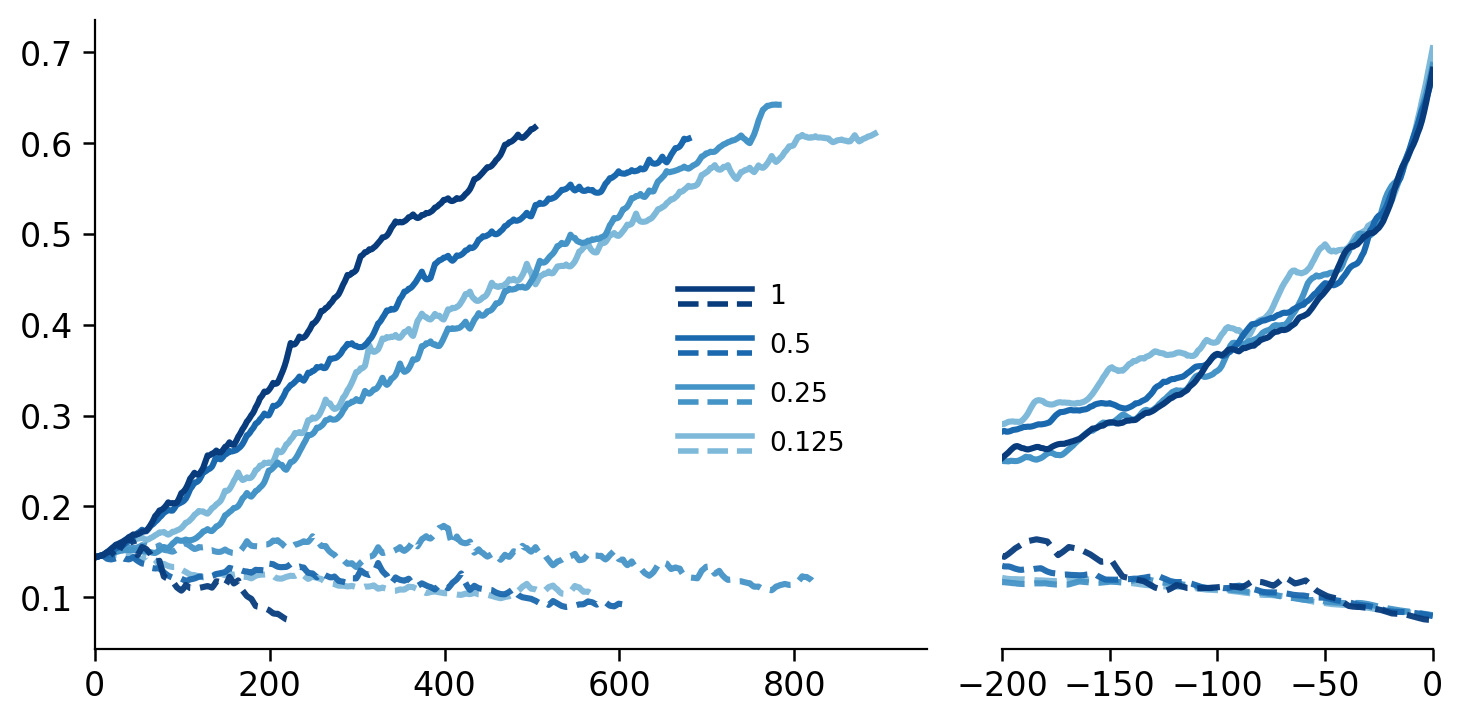

saved_png /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4/fig4_edge_population_fig5c_style.png
saved_pdf /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4/fig4_edge_population_fig5c_style.pdf


In [24]:
coherences = np.array([item['coherence'] for item in datasets], dtype=float)
colors = dict(zip(coherences, plt.cm.Blues(np.linspace(0.45, 0.95, len(coherences)))))

fig, (ax_stim, ax_rt) = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.5),
    sharey=True,
    gridspec_kw={'width_ratios': [1.45, 0.75], 'wspace': 0.04},
    constrained_layout=True,
)

for group in groups:
    style = OUTCOMES[group['outcome_name']]
    color = colors[group['coherence']]
    stop = min(int(round(group['mean_rt'])), len(time_ms) - 1)

    ax_stim.plot(
        time_ms[:stop + 1],
        group['stim_trace'][:stop + 1],
        color=color,
        linestyle=style['linestyle'],
        alpha=style['alpha'],
        linewidth=2.2,
    )

    if group['rt_trace'] is not None:
        rt_axis = np.arange(-RT_ALIGN_WINDOW_MS, 1, dtype=float)
        ax_rt.plot(
            rt_axis,
            group['rt_trace'],
            color=color,
            linestyle=style['linestyle'],
            alpha=style['alpha'],
            linewidth=2.2,
        )

max_plotted_rt = max(int(round(group['mean_rt'])) for group in groups)
ax_stim.set_xlim(0, min(max_plotted_rt + 60, int(time_ms[-1])))
ax_rt.set_xlim(-RT_ALIGN_WINDOW_MS, 0)

ax_stim.set_xlabel('')
ax_rt.set_xlabel('')
ax_stim.set_ylabel('')
ax_rt.set_ylabel('')
ax_stim.set_title('')
ax_rt.set_title('')

for ax in (ax_stim, ax_rt):
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4.2, width=0.9, labelsize=12)

ax_rt.spines['left'].set_visible(False)
ax_rt.tick_params(axis='y', left=False, labelleft=False)
ax_rt.yaxis.set_visible(False)

legend_x0 = 0.70
legend_x1 = 0.79
legend_text_x = 0.81
legend_y0 = 0.56
legend_dy = 0.078
line_gap = 0.012
for row, coh in enumerate(sorted(coherences, reverse=True)):
    y = legend_y0 - row * legend_dy
    color = colors[coh]
    ax_stim.plot([legend_x0, legend_x1], [y + line_gap, y + line_gap], transform=ax_stim.transAxes, color=color, lw=2.0, linestyle='-', clip_on=False)
    ax_stim.plot([legend_x0, legend_x1], [y - line_gap, y - line_gap], transform=ax_stim.transAxes, color=color, lw=2.0, linestyle='--', clip_on=False)
    ax_stim.text(legend_text_x, y, f'{coh:g}', transform=ax_stim.transAxes, fontsize=9.5, ha='left', va='center')

SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(SAVE_PATH, dpi=220, bbox_inches='tight')
fig.savefig(SAVE_PDF_PATH, bbox_inches='tight')
plt.show()
print('saved_png', SAVE_PATH)
print('saved_pdf', SAVE_PDF_PATH)


In [ ]:
bash figures_code/main/figure4/submit_fig4_single_trial_dynamics_scc.sh output-dir results/figure4/fig4_edge_bump_dynamics_1000trials --param-config figures_code/main/figure4/fig4_single_trial_dynamics_wide_config.json
--coherences "0.5 0.25 -0.25 -0.5" --trials-per-coherence 250 batch-trials 250 --dur 2000 --seed 201

## Notes

- This panel follows the logic of Gold & Shadlen Fig.5c rather than the earlier single-neuron example.
- For each coherence, the upper solid trace is correct Tin/right choice and the lower dashed trace is incorrect Tout/left choice in the custom legend.
- Stimulus-aligned curves are truncated at each group's mean RT.
- RT-aligned curves use the final 200 ms before RT.
- All nonempty groups are plotted, including the single c=1.0 incorrect trial.
